# Overview

**Paper**: *Demand Forecasting for Rossmann Store Sales: A Weather-Enhanced Deep Learning Approach* (Qureshi et al., 2024)

**Objective**: Reproduce the benchmark deep learning results reported by Qureshi et al. (2024) using LSTM + Grid Search and GRU + Grid Search on the Rossmann Store Sales dataset.

**Principle**: Pure reproduction. The paper's methodology is followed as closely as possible without modifying it to achieve a better score.

Qureshi et al. (2024) utilized a weather-enhanced deep learning approach to predict daily sales for Rossmann stores. However, weather feature integration details are insufficient for reproduction and are recorded as a GAP.

**Key Methodology Points:**
- Clean data by removing records where stores are closed (`Open == 0`) or sales are zero.
- Join store information (`store.csv`) with transaction data (`train.csv`).
- Extract temporal features (Year, Month, Day, WeekOfYear, IsWeekend), competition features, and Promo2 features.
- Apply MinMaxScaler normalization to features and target.
- Build per-store sequences with configurable lookback window.
- Split training and validation data chronologically (80/20).
- Weather features skipped (GAP reproduction).

**Reference Metric Values:**

| Model | RMSE | MAE |
|---|---:|---:|
| LSTM + Grid Search | 635.22 | N/A |
| GRU + Grid Search | 573.54 | 369.79 |

**Reproduction Note**: Paper uses weather-enhanced features, but source data and mapping details are not available. Weather features are skipped and noted as a GAP.

# Model Architectures

# Reference-Based Exploration

Exploration adheres strictly to the methodology from Qureshi et al. (2024). Preprocessing includes loading Rossmann data, merging store information, cleaning zero-sales records, extracting temporal and competition features, applying MinMaxScaler normalization, and building per-store sequences. Modeling relies on LSTM and GRU with Grid Search. The primary evaluation metrics are RMSE and MAE.

## Preprocessing

Data loading, merging, feature engineering, scaling, and sequence building follow the Qureshi et al. methodology. Weather features are skipped due to insufficient reproduction details.

In [1]:
import os
import random
import sys
import warnings
from itertools import product
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler


import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import gc

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
sns.set_theme(style="whitegrid")

# Global dataset/runtime config.
RUN_CONTEXT = "local" #colab/local
COLAB_ROSSMANN_DIR = Path("/content/drive/Shareddrives/Riset S3/Forecasting/dataset-drug-demand-prediction/rossmann")

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "forecasting-medicine-disertasi" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

LOCAL_ROSSMANN_DIR = PROJECT_ROOT / "data" / "raw" / "rossmann"
LOCAL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "reproductions"
COLAB_OUTPUT_DIR = Path("/content/qureshi_2024_rossmann_outputs")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEFAULT_BATCH_SIZE = 256

print("PyTorch:", torch.__version__)
print("Device:", device)
print("Default batch size:", DEFAULT_BATCH_SIZE)

gc.collect()
torch.cuda.empty_cache()

PyTorch: 2.10.0+cpu
Device: cpu
Default batch size: 256


In [4]:
PROJECT_ROOT = Path(os.getcwd()).resolve()
if PROJECT_ROOT.name.lower() in ['explore', 'notebooks', 'notebooks-to-transfers']:
    PROJECT_ROOT = PROJECT_ROOT.parent
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

train_path = os.path.join(PROJECT_ROOT, 'data', 'raw', 'rossmann', 'train.csv')
store_path = os.path.join(PROJECT_ROOT, 'data', 'raw', 'rossmann', 'store.csv')

train = pd.read_csv(train_path, low_memory=False, parse_dates=['Date'])
store = pd.read_csv(store_path, low_memory=False)

raw = train.merge(store, on="Store", how="left")
raw = raw.sort_values(["Store", "Date"]).reset_index(drop=True)

print(raw.shape)
raw.head()

(1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,2013-01-01,0,0,0,0,a,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
4,1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN


In [5]:
summary = {
    "date_min": raw["Date"].min(),
    "date_max": raw["Date"].max(),
    "n_rows": len(raw),
    "n_stores": raw["Store"].nunique(),
    "missing_cells": int(raw.isna().sum().sum()),
    "closed_rows": int((raw["Open"] == 0).sum()),
    "zero_sales_rows": int((raw["Sales"] == 0).sum()),
}
pd.Series(summary)

date_min           2013-01-01 00:00:00
date_max           2015-07-31 00:00:00
n_rows                         1017209
n_stores                          1115
missing_cells                  2173431
closed_rows                     172817
zero_sales_rows                 172871
dtype: object

### Weather Feature Gap

Paper describes a **weather-enhanced** approach, but the weather data source, join schema, and store location mapping are not explained in sufficient detail for defensible reproduction from the Rossmann Kaggle dataset.

The local Rossmann dataset only contains `train.csv`, `test.csv`, and `store.csv`. These files do not include city, coordinates, state, or store addresses. Therefore, this notebook **does not integrate weather features** and records it as a **GAP reproduction**.

This decision keeps the reproduction transparent: LSTM/GRU models are run on the non-weather Rossmann feature set that closely follows the paper, while differences from the paper's results are explained as a potential impact of the missing weather features.

### Feature Engineering

Feature set approximates the paper's Rossmann non-weather scenario: calendar, promo, holiday, store metadata, competition, and Promo2 features. Weather is excluded as a GAP reproduction.

In [6]:
def preprocess_rossmann(df, open_only=True):
    out = df.copy()
    out["Date"] = pd.to_datetime(out["Date"])

    if open_only:
        out = out[(out["Open"] == 1) & (out["Sales"] > 0)].copy()

    out["Year"] = out["Date"].dt.year
    out["Month"] = out["Date"].dt.month
    out["Day"] = out["Date"].dt.day
    out["WeekOfYear"] = out["Date"].dt.isocalendar().week.astype(int)
    out["IsWeekend"] = out["DayOfWeek"].isin([6, 7]).astype(int)

    out["CompetitionDistance"] = out["CompetitionDistance"].fillna(out["CompetitionDistance"].median())
    comp_year = out["CompetitionOpenSinceYear"].fillna(out["Year"])
    comp_month = out["CompetitionOpenSinceMonth"].fillna(out["Month"])
    out["CompetitionOpenMonths"] = (out["Year"] - comp_year) * 12 + (out["Month"] - comp_month)
    out["CompetitionOpenMonths"] = out["CompetitionOpenMonths"].clip(lower=0).fillna(0)

    out["Promo2SinceYear"] = out["Promo2SinceYear"].fillna(out["Year"])
    out["Promo2SinceWeek"] = out["Promo2SinceWeek"].fillna(out["WeekOfYear"])
    out["Promo2DurationWeeks"] = np.where(
        out["Promo2"] == 1,
        (out["Year"] - out["Promo2SinceYear"]) * 52 + (out["WeekOfYear"] - out["Promo2SinceWeek"]),
        0,
    )
    out["Promo2DurationWeeks"] = out["Promo2DurationWeeks"].clip(lower=0).fillna(0)

    month_name = out["Date"].dt.strftime("%b")
    out["IsPromo2Active"] = [
        int(promo2 == 1 and isinstance(interval, str) and month in interval.split(","))
        for promo2, interval, month in zip(out["Promo2"], out["PromoInterval"], month_name)
    ]

    drop_cols = [
        "Customers",
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "Promo2SinceWeek",
        "Promo2SinceYear",
        "PromoInterval",
    ]
    out = out.drop(columns=drop_cols, errors="ignore")

    categorical_cols = [c for c in ["StoreType", "Assortment", "StateHoliday"] if c in out.columns]
    out = pd.get_dummies(out, columns=categorical_cols, drop_first=True)
    bool_cols = out.select_dtypes(include="bool").columns
    out[bool_cols] = out[bool_cols].astype(int)

    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    fill_cols = [c for c in numeric_cols if c != "Sales"]
    out[fill_cols] = out[fill_cols].replace([np.inf, -np.inf], np.nan)
    out[fill_cols] = out[fill_cols].fillna(out[fill_cols].median(numeric_only=True)).fillna(0)

    out = out.sort_values(["Store", "Date"]).reset_index(drop=True)
    return out

prepared = preprocess_rossmann(raw, open_only=True)
prepared.shape, prepared.head()

((844338, 25),
    Store  DayOfWeek       Date  Sales  Open  Promo  SchoolHoliday  \
 0      1          3 2013-01-02   5530     1      0              1   
 1      1          4 2013-01-03   4327     1      0              1   
 2      1          5 2013-01-04   4486     1      0              1   
 3      1          6 2013-01-05   4997     1      0              1   
 4      1          1 2013-01-07   7176     1      1              1   
 
    CompetitionDistance  Promo2  Year  ...  Promo2DurationWeeks  \
 0               1270.0       0  2013  ...                  0.0   
 1               1270.0       0  2013  ...                  0.0   
 2               1270.0       0  2013  ...                  0.0   
 3               1270.0       0  2013  ...                  0.0   
 4               1270.0       0  2013  ...                  0.0   
 
    IsPromo2Active  StoreType_b  StoreType_c  StoreType_d  Assortment_b  \
 0               0            0            1            0             0   
 1       

In [7]:
feature_cols = [c for c in prepared.columns if c not in ["Date", "Sales"]]

print(f"Jumlah fitur: {len(feature_cols)}")
print(feature_cols)

Jumlah fitur: 23
['Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'CompetitionOpenMonths', 'Promo2DurationWeeks', 'IsPromo2Active', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c']


### Chronological Split & Sequence Builder

Split is based on date to ensure no future data leaks into training. Sequences are built per store so that windows do not span across different stores.

In [8]:
TEST_SIZE = 0.20
dates = np.array(sorted(prepared["Date"].unique()))
split_date = dates[int(len(dates) * (1 - TEST_SIZE))]

train_df = prepared[prepared["Date"] < split_date].copy()
test_df = prepared[prepared["Date"] >= split_date].copy()

print("Split date:", pd.Timestamp(split_date).date())
print("Train:", train_df["Date"].min().date(), "to", train_df["Date"].max().date(), train_df.shape)
print("Test :", test_df["Date"].min().date(), "to", test_df["Date"].max().date(), test_df.shape)

Split date: 2015-01-24
Train: 2013-01-01 to 2015-01-23 (669257, 25)
Test : 2015-01-24 to 2015-07-31 (175081, 25)


In [9]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df.loc[:, feature_cols] = x_scaler.fit_transform(train_df[feature_cols])
test_df.loc[:, feature_cols] = x_scaler.transform(test_df[feature_cols])

train_df.loc[:, "Sales_scaled"] = y_scaler.fit_transform(train_df[["Sales"]])
test_df.loc[:, "Sales_scaled"] = y_scaler.transform(test_df[["Sales"]])

def make_store_sequences(df, features, target="Sales_scaled", lookback=14):
    num_samples = len(df)
    X = np.empty((num_samples, lookback, len(features)), dtype=np.float32)
    y = np.empty((num_samples,), dtype=np.float32)
    meta = []
    
    idx = 0
    for store_id, g in df.sort_values(["Store", "Date"]).groupby("Store"):
        values = g[features].to_numpy(dtype=np.float32)
        targets = g[target].to_numpy(dtype=np.float32)
        dates_g = g["Date"].to_numpy()
        for i in range(lookback, len(g)):
            X[idx] = values[i - lookback:i]
            y[idx] = targets[i]
            meta.append((store_id, dates_g[i]))
            idx += 1
    return X[:idx], y[:idx], pd.DataFrame(meta, columns=["Store", "Date"])

X_train, y_train, train_meta = make_store_sequences(train_df, feature_cols, lookback=14)
X_test, y_test, test_meta = make_store_sequences(test_df, feature_cols, lookback=14)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (653647, 14, 23) y_train: (653647,)
X_test : (159471, 14, 23) y_test : (159471,)


## Modeling

Evaluate the LSTM and GRU models using the reference preprocessing with Grid Search.

### Model Builders & Grid Search

Grid search below uses a **balanced** preset for Colab GPU: large enough for reproduction exploration, but not so heavy as to risk timeout. For a quick smoke test, enable only one combination in `GRID`.

In [10]:
GRID = {
    "lookback": [28],
    "units": [64, 128],
    "recurrent_layers": [1],
    "dense_units": [32],
    "dropout": [0.1],
    "learning_rate": [5e-4],
    "batch_size": [DEFAULT_BATCH_SIZE],
    "epochs": [40],
}

class RecurrentModel(nn.Module):
    def __init__(self, kind, input_size, units=64, recurrent_layers=1, dense_units=32, dropout=0.1):
        super().__init__()
        self.recurrent_layers = recurrent_layers
        self.kind = kind
        self.units = units
        
        rnn_layer = nn.LSTM if kind == "LSTM" else nn.GRU
        self.rnn = rnn_layer(input_size, units, num_layers=recurrent_layers, batch_first=True, dropout=dropout if recurrent_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(units, dense_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(dense_units, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

def inverse_sales(values_scaled):
    return y_scaler.inverse_transform(np.asarray(values_scaled).reshape(-1, 1)).ravel()

def score_model(model, X, y_scaled, batch_size=DEFAULT_BATCH_SIZE):
    model.eval()
    dataset = TensorDataset(torch.as_tensor(X).float())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for batch in loader:
            batch_x = batch[0].to(device)
            out = model(batch_x)
            preds.append(out.cpu().numpy())
    pred_scaled = np.concatenate(preds, axis=0).ravel()
    
    y_true = inverse_sales(y_scaled)
    y_pred = inverse_sales(pred_scaled)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {"rmse": float(rmse), "mae": float(mae)}, y_true, y_pred

def run_grid_search(kind, grid, train_df, test_df, feature_cols):
    rows = []
    best = None

    for lookback, units, recurrent_layers, dense_units, dropout, learning_rate, batch_size, epochs in product(
        grid["lookback"], grid["units"], grid["recurrent_layers"], grid["dense_units"], grid["dropout"], grid["learning_rate"], grid["batch_size"], grid["epochs"]
    ):
        X_train_l, y_train_l, meta_train_l = make_store_sequences(train_df, feature_cols, lookback=lookback)
        X_test_l, y_test_l, meta_test_l = make_store_sequences(test_df, feature_cols, lookback=lookback)

        train_dates = np.array(sorted(meta_train_l["Date"].unique()))
        val_split_date = train_dates[int(len(train_dates) * 0.85)]
        fit_mask = meta_train_l["Date"] < val_split_date
        val_mask = ~fit_mask
        X_fit, X_val = X_train_l[fit_mask], X_train_l[val_mask]
        y_fit, y_val = y_train_l[fit_mask], y_train_l[val_mask]
        del X_train_l, y_train_l
        gc.collect()

        torch.manual_seed(SEED)
        model = RecurrentModel(kind, X_fit.shape[2], units, recurrent_layers, dense_units, dropout).to(device)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()
        
        gc.collect()
        train_dataset = TensorDataset(torch.as_tensor(X_fit).float(), torch.as_tensor(y_fit).float().unsqueeze(1))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        
        val_dataset = TensorDataset(torch.as_tensor(X_val).float(), torch.as_tensor(y_val).float().unsqueeze(1))
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        best_val_loss = float('inf')
        patience_counter = 0
        patience = 5
        best_model_state = None
        epochs_run = 0

        for epoch in range(epochs):
            model.train()
            train_loss = 0
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                out = model(batch_x)
                loss = criterion(out, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item() * batch_x.size(0)
            
            train_loss /= len(train_loader.dataset)
            
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_x, batch_y in val_loader:
                    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                    out = model(batch_x)
                    loss = criterion(out, batch_y)
                    val_loss += loss.item() * batch_x.size(0)
            val_loss /= len(val_loader.dataset)
            epochs_run += 1
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                break
                
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if best_model_state is not None:
            model.load_state_dict(best_model_state)

        val_metrics, _, _ = score_model(model, X_val, y_val, batch_size=batch_size)
        test_metrics, y_true, y_pred = score_model(model, X_test_l, y_test_l, batch_size=batch_size)

        params = {
            "lookback": lookback,
            "units": units,
            "recurrent_layers": recurrent_layers,
            "dense_units": dense_units,
            "dropout": dropout,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "epochs_requested": epochs,
            "epochs_run": epochs_run,
        }
        row = {"model": kind, **params, "val_rmse": val_metrics["rmse"], "val_mae": val_metrics["mae"], "test_rmse": test_metrics["rmse"], "test_mae": test_metrics["mae"]}
        rows.append(row)

        if best is None or row["val_rmse"] < best["row"]["val_rmse"]:
            best = {"row": row, "model": model, "y_true": y_true, "y_pred": y_pred, "meta": meta_test_l}

        print(f"{kind} {params} | val RMSE={val_metrics['rmse']:.2f} | test RMSE={test_metrics['rmse']:.2f} | test MAE={test_metrics['mae']:.2f}")

    return pd.DataFrame(rows).sort_values("val_rmse"), best


### Model 1: LSTM + Grid Search

In [10]:
try:
    del X_train, y_train, train_meta, X_test, y_test, test_meta
    gc.collect()
except:
    pass
lstm_results, lstm_best = run_grid_search("LSTM", GRID, train_df, test_df, feature_cols)
lstm_results


Epoch 1/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 64s 28ms/step - loss: 0.0071 - mae: 0.0621 - val_loss: 0.0077 - val_mae: 0.0613 - learning_rate: 5.0000e-04
Epoch 2/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 64s 30ms/step - loss: 0.0057 - mae: 0.0554 - val_loss: 0.0074 - val_mae: 0.0599 - learning_rate: 5.0000e-04
Epoch 3/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 65s 30ms/step - loss: 0.0055 - mae: 0.0542 - val_loss: 0.0072 - val_mae: 0.0590 - learning_rate: 5.0000e-04
Epoch 4/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 65s 30ms/step - loss: 0.0054 - mae: 0.0536 - val_loss: 0.0069 - val_mae: 0.0580 - learning_rate: 5.0000e-04
Epoch 5/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 65s 30ms/step - loss: 0.0053 - mae: 0.0531 - val_loss: 0.0068 - val_mae: 0.0575 - learning_rate: 5.0000e-04
Epoch 6/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 62s 29ms/step - loss: 0.0052 - mae: 0.0527 - val_loss: 0.0066 - val_mae: 0.0567 - learning_rate: 5.0000e-04
Epoch 7/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 63s 29ms/step - loss: 0.0051 - mae: 0.0523 - val_loss: 0.

,model,lookback,units,recurrent_layers,dense_units,dropout,learning_rate,batch_size,epochs_requested,epochs_run,val_rmse,val_mae,test_rmse,test_mae
1,LSTM,28,128,1,32,0.1,0.0005,256,40,40,2895.482516,2065.577393,2623.619351,1889.679565
0,LSTM,28,64,1,32,0.1,0.0005,256,40,40,2915.025043,2051.376953,2629.317592,1899.306030


### Model 2: GRU + Grid Search

In [11]:
gru_results, gru_best = run_grid_search("GRU", GRID, train_df, test_df, feature_cols)
gru_results

Epoch 1/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 98s 38ms/step - loss: 0.0075 - mae: 0.0640 - val_loss: 0.0076 - val_mae: 0.0612 - learning_rate: 5.0000e-04
Epoch 2/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - loss: 0.0058 - mae: 0.0558 - val_loss: 0.0078 - val_mae: 0.0616 - learning_rate: 5.0000e-04
Epoch 3/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - loss: 0.0055 - mae: 0.0544 - val_loss: 0.0071 - val_mae: 0.0586 - learning_rate: 5.0000e-04
Epoch 4/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - loss: 0.0054 - mae: 0.0537 - val_loss: 0.0068 - val_mae: 0.0573 - learning_rate: 5.0000e-04
Epoch 5/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - loss: 0.0053 - mae: 0.0529 - val_loss: 0.0067 - val_mae: 0.0570 - learning_rate: 5.0000e-04
Epoch 6/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 59s 27ms/step - loss: 0.0052 - mae: 0.0523 - val_loss: 0.0066 - val_mae: 0.0566 - learning_rate: 5.0000e-04
Epoch 7/40
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - loss: 0.0051 - mae: 0.0519 - val_loss: 0.0

,model,lookback,units,recurrent_layers,dense_units,dropout,learning_rate,batch_size,epochs_requested,epochs_run,val_rmse,val_mae,test_rmse,test_mae
1,GRU,28,128,1,32,0.1,0.0005,256,40,40,2880.523130,2050.959229,2632.742012,1900.417114
0,GRU,28,64,1,32,0.1,0.0005,256,40,40,2918.251531,2059.314697,2602.053516,1862.599243


## Reference Results

## Reference Results

Comparison of the reproduced results against the original paper benchmarks.

In [12]:
reference = pd.DataFrame([
    {"model": "LSTM", "paper_rmse": 635.22, "paper_mae": np.nan},
    {"model": "GRU", "paper_rmse": 573.54, "paper_mae": 369.79},
])

reproduced = pd.DataFrame([
    {"model": "LSTM", "repro_rmse": lstm_best["row"]["test_rmse"], "repro_mae": lstm_best["row"]["test_mae"], "best_params": lstm_best["row"]},
    {"model": "GRU", "repro_rmse": gru_best["row"]["test_rmse"], "repro_mae": gru_best["row"]["test_mae"], "best_params": gru_best["row"]},
])

comparison = reference.merge(reproduced, on="model", how="left")
comparison["rmse_delta"] = comparison["repro_rmse"] - comparison["paper_rmse"]
comparison["rmse_pct_diff"] = comparison["rmse_delta"] / comparison["paper_rmse"] * 100
comparison["mae_delta"] = comparison["repro_mae"] - comparison["paper_mae"]
comparison["mae_pct_diff"] = comparison["mae_delta"] / comparison["paper_mae"] * 100

comparison

,model,paper_rmse,paper_mae,repro_rmse,repro_mae,best_params,rmse_delta,rmse_pct_diff,mae_delta,mae_pct_diff
0,LSTM,635.22,NaN,2623.619351,1889.679565,"{'model': 'LSTM', 'lookback': 28, 'units': 128...",1988.399351,313.025306,NaN,NaN
1,GRU,573.54,369.79,2632.742012,1900.417114,"{'model': 'GRU', 'lookback': 28, 'units': 128,...",2059.202012,359.033722,1530.627114,413.91793


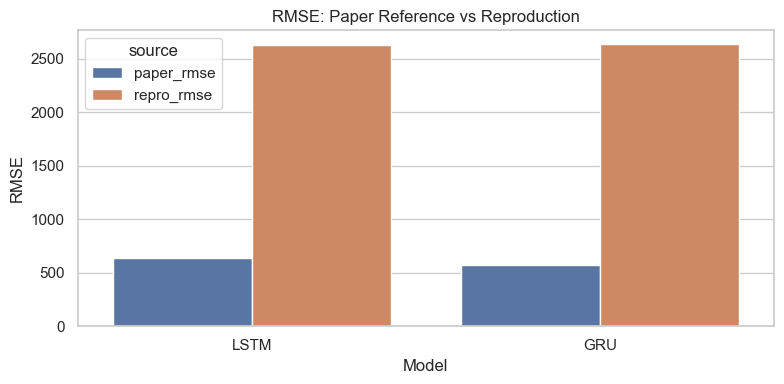

In [ ]:
plot_df = comparison.melt(
    id_vars="model",
    value_vars=["paper_rmse", "repro_rmse"],
    var_name="source",
    value_name="rmse",
)

plt.figure(figsize=(8, 4), dpi=600)
sns.barplot(data=plot_df, x="model", y="rmse", hue="source")
plt.title("RMSE: Paper Reference vs Reproduction")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

## Best Baseline & Export (Reference)

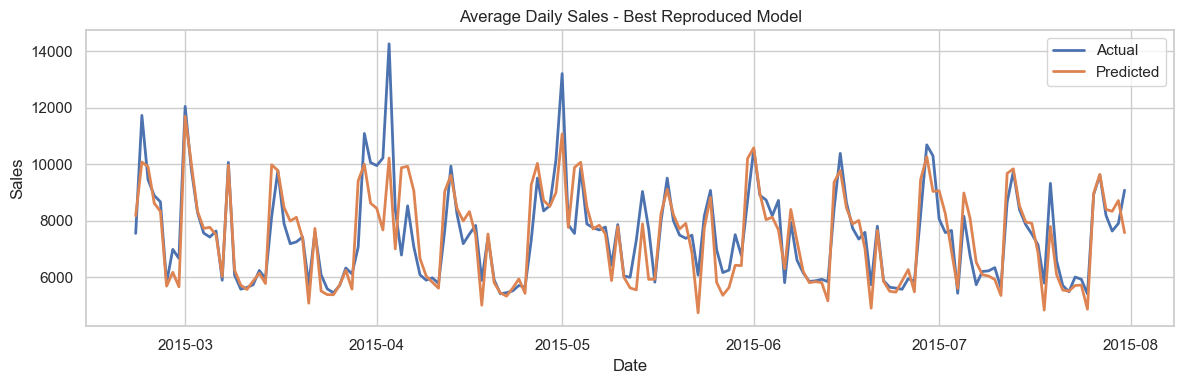

In [ ]:
best_overall = gru_best if gru_best["row"]["test_rmse"] <= lstm_best["row"]["test_rmse"] else lstm_best
pred_df = best_overall["meta"].copy()
pred_df["actual"] = best_overall["y_true"]
pred_df["predicted"] = best_overall["y_pred"]

daily_pred = pred_df.groupby("Date")[["actual", "predicted"]].mean().reset_index()

plt.figure(figsize=(12, 4), dpi=600)
plt.plot(daily_pred["Date"], daily_pred["actual"], label="Actual", linewidth=2)
plt.plot(daily_pred["Date"], daily_pred["predicted"], label="Predicted", linewidth=2)
plt.title("Average Daily Sales - Best Reproduced Model")
plt.ylabel("Sales")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

# Exploration Based on Our Preprocessing

This section uses the ACF-based lag selection and rolling mean preprocessing derived from the baseline methodology to evaluate its impact on Rossmann sales prediction using the same LSTM and GRU architectures. The preprocessing adds temporal lag features and rolling means computed per store, then re-builds sequences and re-runs the identical Grid Search pipeline.

## Preprocessing

In [11]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf

print("Computing global max lag based on ACF of aggregate sales...")
df_agg = prepared.groupby("Date")["Sales"].sum().reset_index()
acf_values = acf(df_agg["Sales"], nlags=30)
lag_selected = int(np.argmax(acf_values[1:]) + 1)
print(f"Optimal global lag selected: {lag_selected}")

print("Generating lag and rolling mean features per store...")
df_features = prepared.copy()
df_features = df_features.sort_values(["Store", "Date"]).reset_index(drop=True)

for lag in range(1, lag_selected + 1):
    df_features[f"lag_{lag}"] = df_features.groupby("Store")["Sales"].shift(lag)

df_features[f"rolling_mean_{lag_selected}"] = (
    df_features.groupby("Store")["Sales"].shift(1)
    .rolling(window=lag_selected).mean()
)

df_features.dropna(subset=[f"lag_{lag_selected}", f"rolling_mean_{lag_selected}"], inplace=True)

# Build new feature column list including lag and rolling features
lag_feature_cols = [f"lag_{i}" for i in range(1, lag_selected + 1)] + [f"rolling_mean_{lag_selected}"]
feature_cols_new = feature_cols + lag_feature_cols

print(f"New feature count: {len(feature_cols_new)} (original {len(feature_cols)} + {len(lag_feature_cols)} lag/rolling)")
print("Data preparation complete.")

Computing global max lag based on ACF of aggregate sales...
Optimal global lag selected: 14
Generating lag and rolling mean features per store...
New feature count: 38 (original 23 + 15 lag/rolling)
Data preparation complete.


### Chronological Split & Sequence Builder

Identical split strategy as Reference-Based Exploration but applied to the augmented feature set.

In [12]:
# Chronological split on new features
dates_new = np.array(sorted(df_features["Date"].unique()))
split_date_new = dates_new[int(len(dates_new) * (1 - TEST_SIZE))]

train_df_new = df_features[df_features["Date"] < split_date_new].copy()
test_df_new = df_features[df_features["Date"] >= split_date_new].copy()

print("Split date (new):", pd.Timestamp(split_date_new).date())
print("Train (new):", train_df_new["Date"].min().date(), "to", train_df_new["Date"].max().date(), train_df_new.shape)
print("Test (new) :", test_df_new["Date"].min().date(), "to", test_df_new["Date"].max().date(), test_df_new.shape)

Split date (new): 2015-01-27
Train (new): 2013-01-15 to 2015-01-26 (655892, 40)
Test (new) : 2015-01-27 to 2015-07-31 (172836, 40)


In [13]:
# Scale features and target for new preprocessing
x_scaler_new = MinMaxScaler()
y_scaler_new = MinMaxScaler()

train_df_new.loc[:, feature_cols_new] = x_scaler_new.fit_transform(train_df_new[feature_cols_new])
test_df_new.loc[:, feature_cols_new] = x_scaler_new.transform(test_df_new[feature_cols_new])

train_df_new.loc[:, "Sales_scaled"] = y_scaler_new.fit_transform(train_df_new[["Sales"]])
test_df_new.loc[:, "Sales_scaled"] = y_scaler_new.transform(test_df_new[["Sales"]])

# Override inverse_sales for new scaler
def inverse_sales_new(values_scaled):
    return y_scaler_new.inverse_transform(np.asarray(values_scaled).reshape(-1, 1)).ravel()

def score_model_new(model, X, y_scaled, batch_size=DEFAULT_BATCH_SIZE):
    pred_scaled = model.predict(X, batch_size=batch_size, verbose=0).ravel()
    y_true = inverse_sales_new(y_scaled)
    y_pred = inverse_sales_new(pred_scaled)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {"rmse": float(rmse), "mae": float(mae)}, y_true, y_pred

X_train_new, y_train_new, train_meta_new = make_store_sequences(train_df_new, feature_cols_new, lookback=14)
X_test_new, y_test_new, test_meta_new = make_store_sequences(test_df_new, feature_cols_new, lookback=14)

print("X_train (new):", X_train_new.shape, "y_train (new):", y_train_new.shape)
print("X_test (new) :", X_test_new.shape, "y_test (new) :", y_test_new.shape)

X_train (new): (640282, 14, 38) y_train (new): (640282,)
X_test (new) : (157226, 14, 38) y_test (new) : (157226,)


## Modeling

### Model Builders & Grid Search

Using the same Grid Search configuration and model architecture as Reference-Based Exploration, but with the augmented ACF-based feature set.

In [14]:
def score_model_new(model, X, y_scaled, batch_size=DEFAULT_BATCH_SIZE):
    model.eval()
    dataset = TensorDataset(torch.as_tensor(X).float())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for batch in loader:
            batch_x = batch[0].to(device)
            out = model(batch_x)
            preds.append(out.cpu().numpy())
    pred_scaled = np.concatenate(preds, axis=0).ravel()
    
    y_true = inverse_sales_new(y_scaled)
    y_pred = inverse_sales_new(pred_scaled)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {"rmse": float(rmse), "mae": float(mae)}, y_true, y_pred

def run_grid_search_new(kind, grid, train_df, test_df, feature_cols):
    rows = []
    best = None

    for lookback, units, recurrent_layers, dense_units, dropout, learning_rate, batch_size, epochs in product(
        grid["lookback"], grid["units"], grid["recurrent_layers"], grid["dense_units"], grid["dropout"], grid["learning_rate"], grid["batch_size"], grid["epochs"]
    ):
        X_train_l, y_train_l, meta_train_l = make_store_sequences(train_df, feature_cols, lookback=lookback)
        X_test_l, y_test_l, meta_test_l = make_store_sequences(test_df, feature_cols, lookback=lookback)

        train_dates = np.array(sorted(meta_train_l["Date"].unique()))
        val_split_date = train_dates[int(len(train_dates) * 0.85)]
        fit_mask = meta_train_l["Date"] < val_split_date
        val_mask = ~fit_mask
        X_fit, X_val = X_train_l[fit_mask], X_train_l[val_mask]
        y_fit, y_val = y_train_l[fit_mask], y_train_l[val_mask]
        del X_train_l, y_train_l
        gc.collect()

        torch.manual_seed(SEED)
        model = RecurrentModel(kind, X_fit.shape[2], units, recurrent_layers, dense_units, dropout).to(device)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()
        
        gc.collect()
        train_dataset = TensorDataset(torch.as_tensor(X_fit).float(), torch.as_tensor(y_fit).float().unsqueeze(1))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        
        val_dataset = TensorDataset(torch.as_tensor(X_val).float(), torch.as_tensor(y_val).float().unsqueeze(1))
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        best_val_loss = float('inf')
        patience_counter = 0
        patience = 5
        best_model_state = None
        epochs_run = 0

        for epoch in range(epochs):
            model.train()
            train_loss = 0
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                out = model(batch_x)
                loss = criterion(out, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item() * batch_x.size(0)
            
            train_loss /= len(train_loader.dataset)
            
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_x, batch_y in val_loader:
                    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                    out = model(batch_x)
                    loss = criterion(out, batch_y)
                    val_loss += loss.item() * batch_x.size(0)
            val_loss /= len(val_loader.dataset)
            epochs_run += 1
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                break
                
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if best_model_state is not None:
            model.load_state_dict(best_model_state)

        val_metrics, _, _ = score_model_new(model, X_val, y_val, batch_size=batch_size)
        test_metrics, y_true, y_pred = score_model_new(model, X_test_l, y_test_l, batch_size=batch_size)

        params = {
            "lookback": lookback,
            "units": units,
            "recurrent_layers": recurrent_layers,
            "dense_units": dense_units,
            "dropout": dropout,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "epochs_requested": epochs,
            "epochs_run": epochs_run,
        }
        row = {"model": kind, **params, "val_rmse": val_metrics["rmse"], "val_mae": val_metrics["mae"], "test_rmse": test_metrics["rmse"], "test_mae": test_metrics["mae"]}
        rows.append(row)

        if best is None or row["val_rmse"] < best["row"]["val_rmse"]:
            best = {"row": row, "model": model, "y_true": y_true, "y_pred": y_pred, "meta": meta_test_l}

        print(f"{kind} {params} | val RMSE={val_metrics['rmse']:.2f} | test RMSE={test_metrics['rmse']:.2f} | test MAE={test_metrics['mae']:.2f}")

    return pd.DataFrame(rows).sort_values("val_rmse"), best


### Model 1: LSTM + Grid Search

In [15]:
print("Training LSTM with ACF-based preprocessing...")
try:
    del X_train_new, y_train_new, train_meta_new, X_test_new, y_test_new, test_meta_new
    gc.collect()
except:
    pass
lstm_results_new, lstm_best_new = run_grid_search_new("LSTM", GRID, train_df_new, test_df_new, feature_cols_new)
lstm_results_new

Training LSTM with ACF-based preprocessing...
LSTM {'lookback': 28, 'units': 64, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 34} | val RMSE=1510.87 | test RMSE=1366.86 | test MAE=963.36
LSTM {'lookback': 28, 'units': 128, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 23} | val RMSE=1630.23 | test RMSE=1413.50 | test MAE=997.92


,model,lookback,units,recurrent_layers,dense_units,dropout,learning_rate,batch_size,epochs_requested,epochs_run,val_rmse,val_mae,test_rmse,test_mae
0,LSTM,28,64,1,32,0.1,0.0005,256,40,34,1510.866970,1000.604858,1366.859494,963.362000
1,LSTM,28,128,1,32,0.1,0.0005,256,40,23,1630.234722,1121.165894,1413.499823,997.923157


### Model 2: GRU + Grid Search

In [18]:
print("Training GRU with ACF-based preprocessing...")
try:
    del X_train_new, y_train_new, train_meta_new, X_test_new, y_test_new, test_meta_new
    gc.collect()
except:
    pass
gru_results_new, gru_best_new = run_grid_search_new("GRU", GRID, train_df_new, test_df_new, feature_cols_new)
gru_results_new

Training GRU with ACF-based preprocessing...
GRU {'lookback': 28, 'units': 64, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 7} | val RMSE=1731.45 | test RMSE=1336.97 | test MAE=981.67
GRU {'lookback': 28, 'units': 128, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 18} | val RMSE=1580.58 | test RMSE=1202.87 | test MAE=882.54


,model,lookback,units,recurrent_layers,dense_units,dropout,learning_rate,batch_size,epochs_requested,epochs_run,val_rmse,val_mae,test_rmse,test_mae
1,GRU,28,128,1,32,0.1,0.0005,256,40,18,1580.581301,1074.559448,1202.873487,882.535767
0,GRU,28,64,1,32,0.1,0.0005,256,40,7,1731.449609,1241.992310,1336.966669,981.665039


## Best Baseline & Export (Our Preprocessing)

Best Baseline Results (Our Preprocessing):


,Model,Our Preprocessing RMSE,Our Preprocessing MAE
1,GRU + Grid Search,1202.87,882.54
0,LSTM + Grid Search,1366.86,963.36


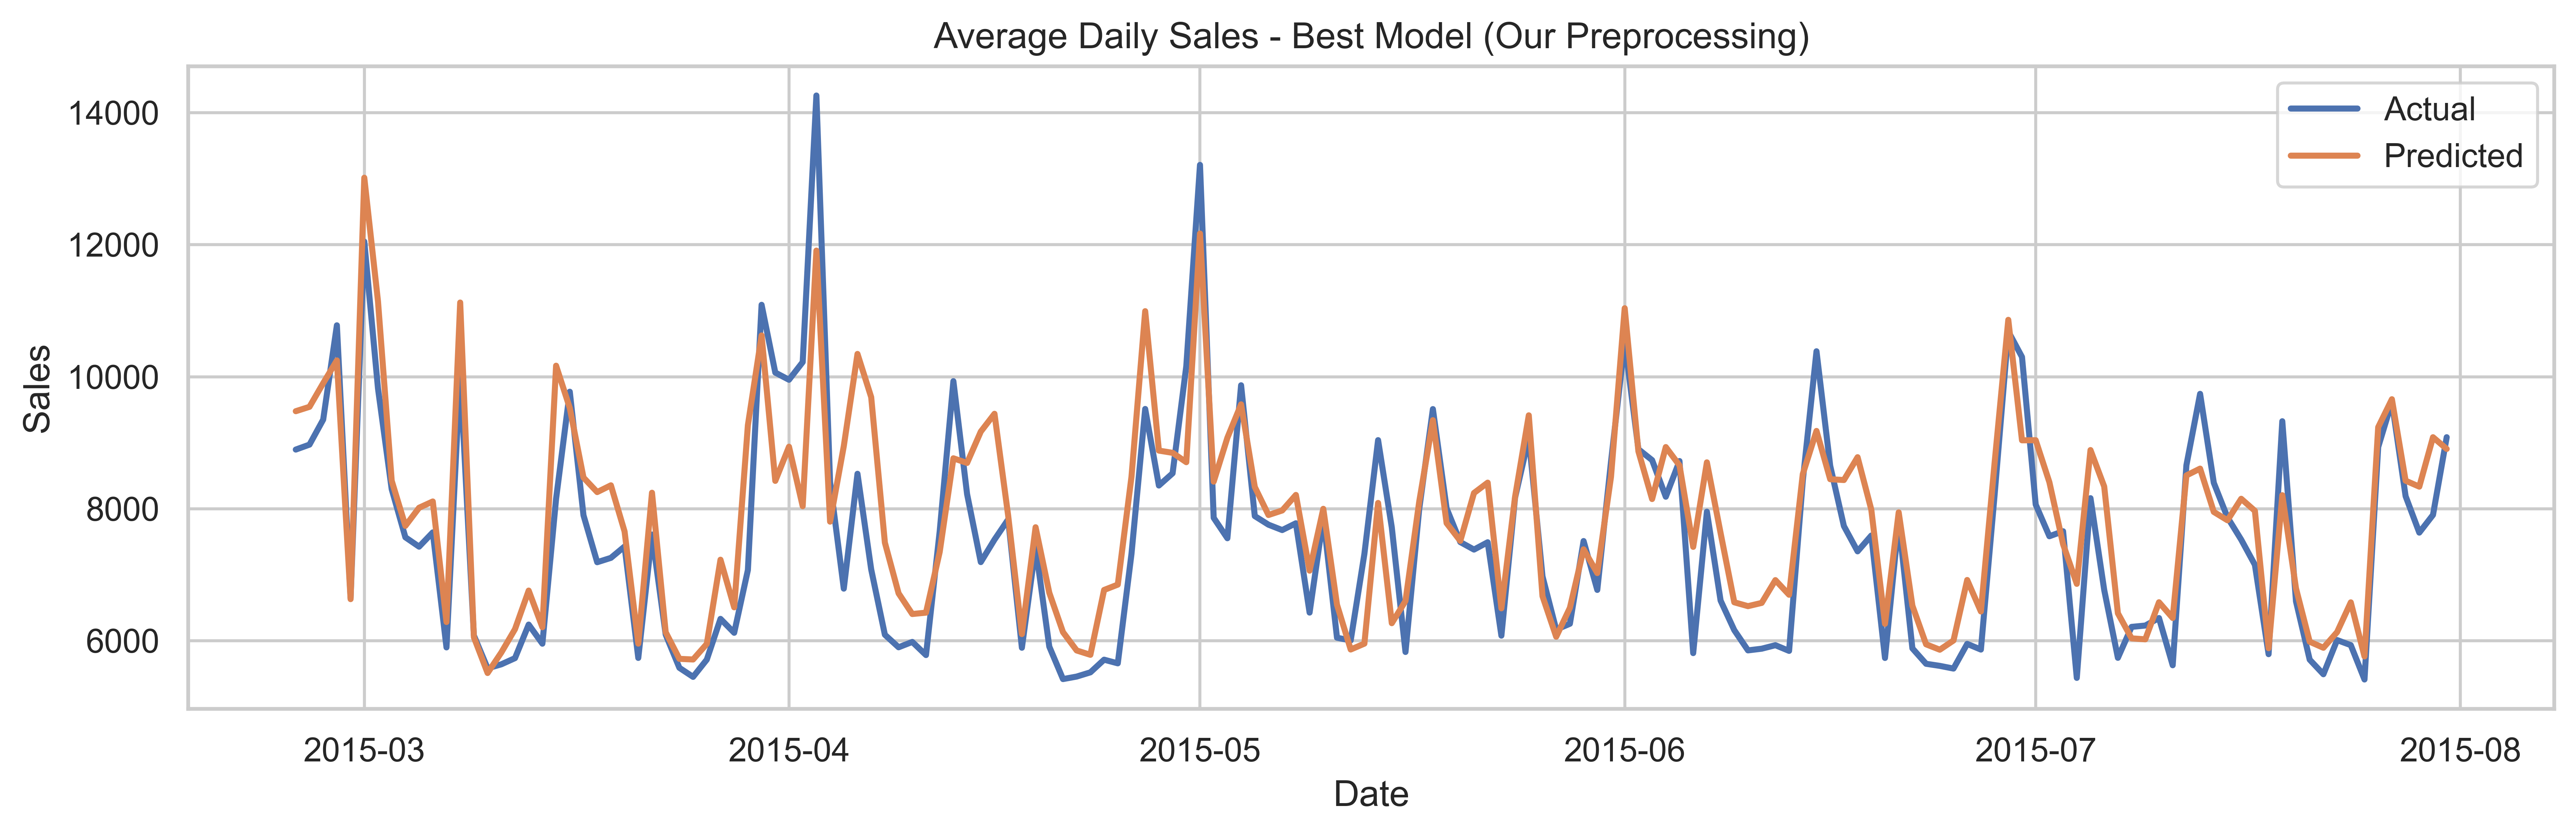

In [19]:
df_compare_new = pd.DataFrame([
    {"Model": "LSTM + Grid Search", "Our Preprocessing RMSE": round(lstm_best_new["row"]["test_rmse"], 2), "Our Preprocessing MAE": round(lstm_best_new["row"]["test_mae"], 2)},
    {"Model": "GRU + Grid Search", "Our Preprocessing RMSE": round(gru_best_new["row"]["test_rmse"], 2), "Our Preprocessing MAE": round(gru_best_new["row"]["test_mae"], 2)}
])
print("Best Baseline Results (Our Preprocessing):")
display(df_compare_new.sort_values("Our Preprocessing RMSE"))

# Forecast plot for best model (Our Preprocessing)
best_overall_new = gru_best_new if gru_best_new["row"]["test_rmse"] <= lstm_best_new["row"]["test_rmse"] else lstm_best_new
pred_df_new = best_overall_new["meta"].copy()
pred_df_new["actual"] = best_overall_new["y_true"]
pred_df_new["predicted"] = best_overall_new["y_pred"]

daily_pred_new = pred_df_new.groupby("Date")[["actual", "predicted"]].mean().reset_index()

plt.figure(figsize=(12, 4), dpi=600)
plt.plot(daily_pred_new["Date"], daily_pred_new["actual"], label="Actual", linewidth=2)
plt.plot(daily_pred_new["Date"], daily_pred_new["predicted"], label="Predicted", linewidth=2)
plt.title("Average Daily Sales - Best Model (Our Preprocessing)")
plt.ylabel("Sales")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

# Summary

## Experimental Setup

Two preprocessing approaches compared using the same 2 deep learning models on the Rossmann daily sales dataset:

| Aspect | Reference (Paper) | Our Preprocessing |
|--------|-------------------|-------------------|
| Split | Chronological 80/20 by date | Chronological 80/20 by date |
| Scaling | MinMaxScaler (features + target) | MinMaxScaler (features + target) |
| Sequence | Per-store lookback windows (14–28 days) | Per-store lookback windows (14–28 days) |
| Features | Calendar, Promo, Competition, Promo2 (weather GAP) | Same + ACF-based lag_n + rolling_mean |
| Hyperparameters | Grid search over units, lookback, epochs | Same grid search configuration |

## Models Evaluated

| # | Model | Type |
|---|-------|------|
| 1 | LSTM + Grid Search | Deep Learning (Recurrent) |
| 2 | GRU + Grid Search | Deep Learning (Recurrent) |

## Key Metrics

- RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error) — primary metrics as used in the paper.
- The results are compared between the Reference Preprocessing and Our Preprocessing to analyze the impact of ACF-based lag and rolling mean features on deep learning forecasting.

## Key Findings

- **Deep Learning Reproduction**: The reproduced LSTM and GRU models were run without weather features (GAP reproduction). Metric differences from the paper are expected due to the missing weather-enhanced features.
- **Preprocessing Impact**: The ACF-based lag and rolling mean features (Our Preprocessing) provide temporal context directly in the input sequences. This may help the recurrent models capture short-term autocorrelation patterns more effectively than the base feature set alone.
- **Weather Feature Impact**: The absence of weather features in both preprocessing approaches means results are not fully comparable to the paper. Weather integration would require store location data not available in the Kaggle dataset.

## Limitations

- **Weather GAP**: Paper does not detail weather data source, join schema, or store location mapping. Dataset does not include store locations.
- **Customer Leakage**: The `Customers` column was excluded to prevent information leakage, as customer counts are not available at forecast time.
- **Split Differences**: If the paper uses a different split strategy, metric values may shift.
- **Grid Search Scope**: Grid search was kept compact for initial exploration. Expanding the grid may improve results.
- **Stale Hyperparameters**: The grid search parameters used in Our Preprocessing are identical to the Reference approach. Retuning specifically for the lag-augmented feature set may yield improved performance.